In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [20]:
df = pd.read_csv('/content/train.csv',usecols = ['Age','Fare','Survived'])


In [21]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [22]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [23]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [24]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [26]:
x = df[['Age', 'Fare']]
y = df['Survived']

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [28]:
x_train,y_train

(           Age      Fare
 331  45.500000   28.5000
 733  23.000000   13.0000
 382  32.000000    7.9250
 704  26.000000    7.8542
 813   6.000000   31.2750
 ..         ...       ...
 106  21.000000    7.6500
 270  29.699118   31.0000
 860  41.000000   14.1083
 435  14.000000  120.0000
 102  21.000000   77.2875
 
 [712 rows x 2 columns],
 331    0
 733    0
 382    0
 704    0
 813    0
       ..
 106    1
 270    0
 860    0
 435    1
 102    0
 Name: Survived, Length: 712, dtype: int64)

/tmp/ipykernel_4171/2254198577.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


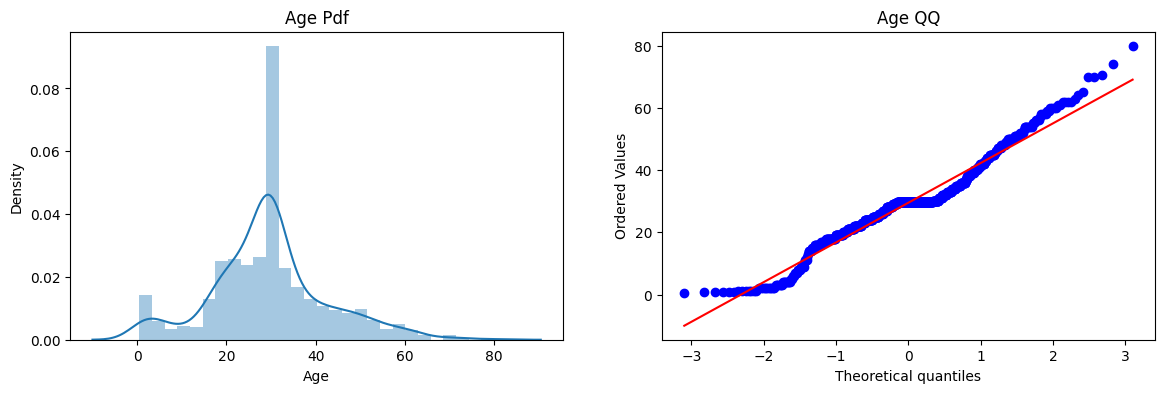

In [29]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age Pdf')

plt.subplot(122)
stats.probplot(x_train['Age'],dist = 'norm',plot = plt)
plt.title('Age QQ')

plt.show()

/tmp/ipykernel_4171/1821036305.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


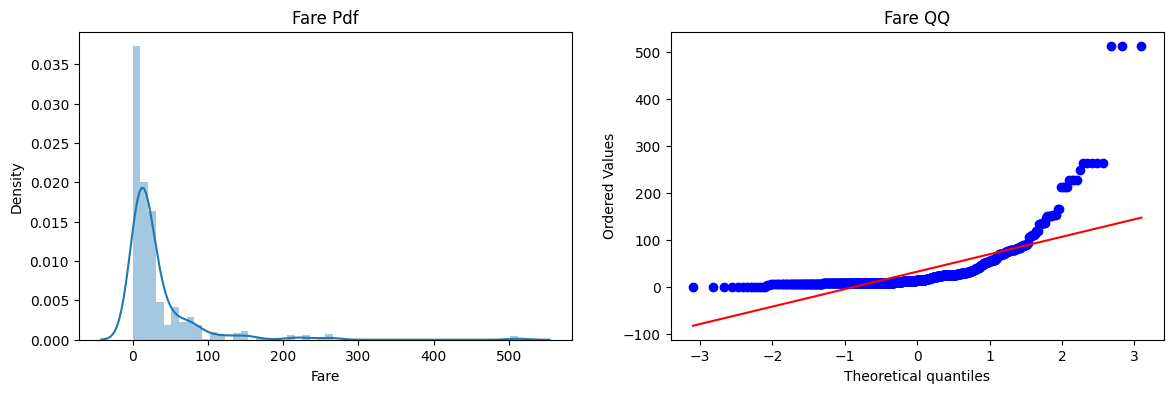

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(x_train['Fare'],dist = 'norm',plot = plt)
plt.title('Fare QQ')

plt.show()

In [31]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [32]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print('The Logistic Regression :',accuracy_score(y_test,y_pred))
print('Decision Tree :',accuracy_score(y_test,y_pred2))

The Logistic Regression : 0.6480446927374302
Decision Tree : 0.659217877094972


In [33]:
trf = FunctionTransformer(func = np.log1p)

In [34]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [35]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [38]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print('The Logistic Regression :',accuracy_score(y_test,y_pred))
print('Decision Tree :',accuracy_score(y_test,y_pred2))

The Logistic Regression : 0.6815642458100558
Decision Tree : 0.6871508379888268


In [41]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Ls :',cross_val_score(clf,X_transformed,y,scoring = 'accuracy',cv = 10).mean())
print('DT :',cross_val_score(clf2,X_transformed,y,scoring = 'accuracy',cv = 10).mean())

Ls : 0.678027465667915
DT : 0.6577403245942572


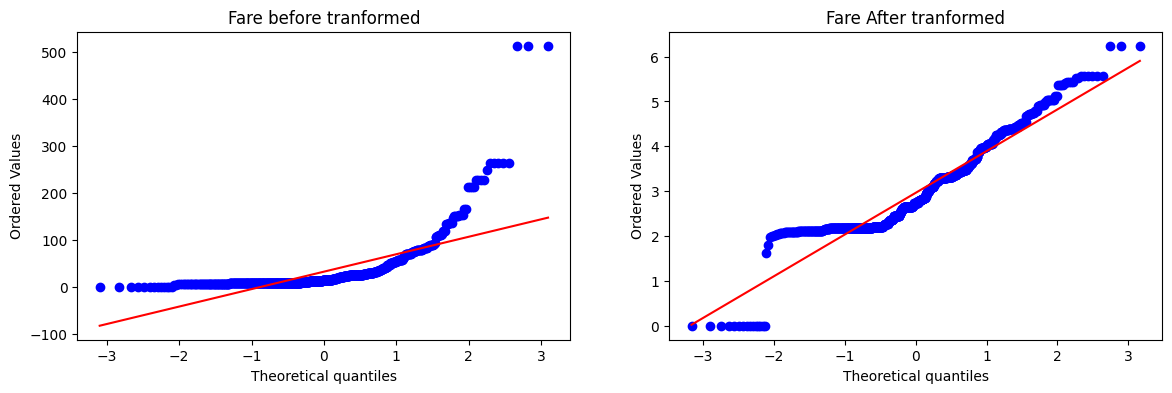

In [48]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'],dist = 'norm',plot = plt)
plt.title('Fare before tranformed')

plt.subplot(122)
stats.probplot(X_transformed['Fare'],dist = 'norm',plot = plt)
plt.title('Fare After tranformed')

plt.show()

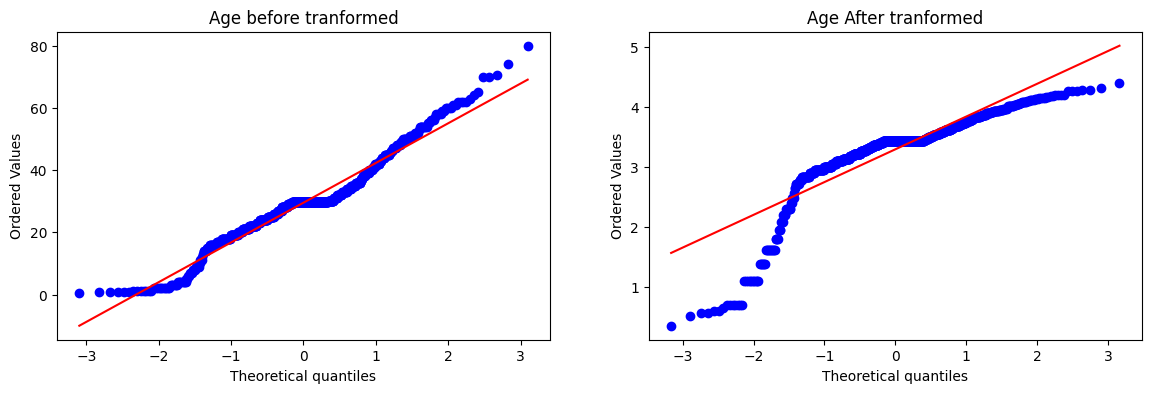

In [49]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'],dist = 'norm',plot = plt)
plt.title('Age before tranformed')

plt.subplot(122)
stats.probplot(X_transformed['Age'],dist = 'norm',plot = plt)
plt.title('Age After tranformed')

plt.show()

In [50]:
print('''
1 .This mean age doesn;t need Log tranformed in this situation
2 .This mean fare need Log tranformed in this situation
''')


1 .This mean age doesn;t need Log tranformed in this situation
2 .This mean fare need Log tranformed in this situation



In [55]:
# So now We only transforemd Fare column and age remind as before

trf2 = ColumnTransformer([(
    'log',FunctionTransformer(np.log1p),
    ['Fare'])],remainder='passthrough'
)

In [68]:
x_train_transformed1 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test)

In [69]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed1,y_train)
clf2.fit(x_train_transformed1,y_train)

y_pred = clf.predict(x_test_transformed2)
y_pred1 = clf2.predict(x_test_transformed2)



In [71]:
print('LS :',accuracy_score(y_test,y_pred))
print('DT :',accuracy_score(y_test,y_pred1))

LS : 0.6703910614525139
DT : 0.6536312849162011


In [72]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Ls :',cross_val_score(clf,X_transformed,y,scoring = 'accuracy',cv = 10).mean())
print('DT :',cross_val_score(clf2,X_transformed,y,scoring = 'accuracy',cv = 10).mean())

Ls : 0.678027465667915
DT : 0.6577028714107366
